## Scene Cropping: Evaluation of PointNet++ MSG


In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import plotly.graph_objects as go
import plotly.express as px

# Verify
print(f"PyTorch       : {torch.__version__}")
import plotly
print(f"Plotly        : {plotly.__version__}")

# Device (MPS on Mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device        : {device}")

# Paths
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

DATA_DIR_M40    = os.path.join(PROJECT_ROOT, "data", "ModelNet40")
CACHE_DIR_M40   = os.path.join(PROJECT_ROOT, "data", "cache_modelnet40_1024pts")
CHECKPOINT_DIR  = os.path.join(PROJECT_ROOT, "checkpoints")
S3DIS_DIR       = os.path.join(PROJECT_ROOT, "data", "S3DIS")

# MSG checkpoint
msg_ckpt_path = os.path.join(CHECKPOINT_DIR, "pointnetpp_msg_best.pt")
assert os.path.exists(msg_ckpt_path), f"MSG checkpoint missing at {msg_ckpt_path}"
print(f"\nMSG checkpoint found: {msg_ckpt_path}")
print(f"  Size: {os.path.getsize(msg_ckpt_path)/1024**2:.1f} MB")

# ModelNet40 classes (what our model knows)
CLASSES_M40 = [
    "airplane", "bathtub", "bed", "bench", "bookshelf", "bottle", "bowl",
    "car", "chair", "cone", "cup", "curtain", "desk", "door", "dresser",
    "flower_pot", "glass_box", "guitar", "keyboard", "lamp", "laptop",
    "mantel", "monitor", "night_stand", "person", "piano", "plant", "radio",
    "range_hood", "sink", "sofa", "stairs", "stool", "table", "tent", "toilet",
    "tv_stand", "vase", "wardrobe", "xbox",
]
CLASS_TO_IDX_M40 = {c: i for i, c in enumerate(CLASSES_M40)}
IDX_TO_CLASS_M40 = {i: c for c, i in CLASS_TO_IDX_M40.items()}

print(f"\nReady. ModelNet40 has {len(CLASSES_M40)} classes.")

PyTorch       : 2.12.0
Plotly        : 6.8.0
Device        : mps

MSG checkpoint found: /Users/dosvatsky/3D Object Detection/checkpoints/pointnetpp_msg_best.pt
  Size: 6.8 MB

Ready. ModelNet40 has 40 classes.


## Defining PointNet++ MSG architecture 

In [2]:
# ===== FPS, Ball Query, index_points =====
def farthest_point_sample(xyz, npoint):
    B, N, _ = xyz.shape
    dev = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=dev)
    distance = torch.full((B, N), float("inf"), device=dev)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=dev)
    batch_idx = torch.arange(B, dtype=torch.long, device=dev)
    for i in range(npoint):
        centroids[:, i] = farthest
        cxyz = xyz[batch_idx, farthest, :].unsqueeze(1)
        dist = ((xyz - cxyz) ** 2).sum(dim=-1)
        distance = torch.minimum(distance, dist)
        farthest = distance.argmax(dim=-1)
    return centroids


def index_points(points, idx):
    B = points.shape[0]
    vs = list(idx.shape); vs[1:] = [1]*(len(vs)-1)
    rs = list(idx.shape); rs[0] = 1
    bi = torch.arange(B, dtype=torch.long, device=points.device).view(vs).repeat(rs)
    return points[bi, idx, :]


def ball_query(radius, nsample, xyz, new_xyz):
    B, N, _ = xyz.shape
    _, S, _ = new_xyz.shape
    dev = xyz.device
    gi = torch.arange(N, dtype=torch.long, device=dev).view(1, 1, N).repeat(B, S, 1)
    sd = ((new_xyz.unsqueeze(2) - xyz.unsqueeze(1)) ** 2).sum(dim=-1)
    gi[sd > radius ** 2] = N
    gi = gi.sort(dim=-1)[0][:, :, :nsample]
    gf = gi[:, :, 0:1].repeat(1, 1, nsample); gi[gi == N] = gf[gi == N]
    return gi


class SetAbstractionMSG(nn.Module):
    def __init__(self, npoint, radii, nsamples, in_channel, mlps):
        super().__init__()
        self.npoint, self.radii, self.nsamples = npoint, radii, nsamples
        self.conv_blocks, self.bn_blocks = nn.ModuleList(), nn.ModuleList()
        for mlp in mlps:
            convs, bns = nn.ModuleList(), nn.ModuleList()
            last = in_channel + 3
            for c in mlp:
                convs.append(nn.Conv2d(last, c, 1)); bns.append(nn.BatchNorm2d(c)); last = c
            self.conv_blocks.append(convs); self.bn_blocks.append(bns)

    def forward(self, xyz, features=None):
        fps = farthest_point_sample(xyz, self.npoint)
        new_xyz = index_points(xyz, fps); outs = []
        for i, (r, k) in enumerate(zip(self.radii, self.nsamples)):
            nn_idx = ball_query(r, k, xyz, new_xyz)
            g_xyz = index_points(xyz, nn_idx) - new_xyz.unsqueeze(2)
            if features is not None:
                g = torch.cat([g_xyz, index_points(features, nn_idx)], dim=-1)
            else:
                g = g_xyz
            g = g.permute(0, 3, 1, 2).contiguous()
            for conv, bn in zip(self.conv_blocks[i], self.bn_blocks[i]):
                g = F.relu(bn(conv(g)))
            outs.append(g.max(dim=-1)[0])
        return new_xyz, torch.cat(outs, dim=1).permute(0, 2, 1).contiguous()


class GlobalSetAbstraction(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        self.convs, self.bns = nn.ModuleList(), nn.ModuleList()
        last = in_channel
        for c in mlp:
            self.convs.append(nn.Conv1d(last, c, 1)); self.bns.append(nn.BatchNorm1d(c)); last = c

    def forward(self, xyz, features):
        x = torch.cat([xyz, features], dim=-1).permute(0, 2, 1)
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))
        return x.max(dim=-1)[0]


class PointNetPlusPlusMSG(nn.Module):
    def __init__(self, num_classes=40, dropout=0.5):
        super().__init__()
        self.sa1 = SetAbstractionMSG(512, [0.1, 0.2, 0.4], [16, 32, 128], 0,
                                     [[32, 32, 64], [64, 64, 128], [64, 96, 128]])
        self.sa2 = SetAbstractionMSG(128, [0.2, 0.4, 0.8], [32, 64, 128], 320,
                                     [[64, 64, 128], [128, 128, 256], [128, 128, 256]])
        self.sa_global = GlobalSetAbstraction(640 + 3, [256, 512, 1024])
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,  num_classes),
        )

    def forward(self, xyz):
        l1_xyz, l1_f = self.sa1(xyz, None)
        l2_xyz, l2_f = self.sa2(l1_xyz, l1_f)
        return self.classifier(self.sa_global(l2_xyz, l2_f))


print("PointNet++ MSG architecture defined.")

PointNet++ MSG architecture defined.


## Loading MSG checkpoint and doing sanity check on one ModelNet40 sample

In [3]:
# Load the trained checkpoint
model = PointNetPlusPlusMSG(num_classes=40, dropout=0.5).to(device)
ckpt = torch.load(msg_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Loaded checkpoint:")
print(f"  Epoch     : {ckpt.get('epoch', '?')}")
print(f"  Val acc   : {ckpt.get('val_acc', '?')}")
print(f"  Weights   : {'EMA' if ckpt.get('is_ema') else 'raw'}")

# Sanity check: run inference on one chair from ModelNet40 cache
# (this confirms the model loads correctly before we feed it real-scene crops)
cache_path = os.path.join(CACHE_DIR_M40, "test.npz")
if os.path.exists(cache_path):
    data = np.load(cache_path)
    points, labels = data["points"], data["labels"]
    chair_idx = int(np.where(labels == CLASS_TO_IDX_M40["chair"])[0][0])
    pts = torch.from_numpy(points[chair_idx]).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(pts)
        pred = logits.argmax(1).item()
        confidence = F.softmax(logits, dim=1).max().item()
    print(f"\nSanity check on a clean ModelNet40 chair:")
    print(f"  True class : chair  (idx {CLASS_TO_IDX_M40['chair']})")
    print(f"  Predicted  : {IDX_TO_CLASS_M40[pred]}  (idx {pred})")
    print(f"  Confidence : {confidence:.3f}")
    print(f"  Correct?   : {pred == CLASS_TO_IDX_M40['chair']}")
else:
    print(f"\nNo ModelNet40 cache at {cache_path} — skipping sanity check.")

Loaded checkpoint:
  Epoch     : 28
  Val acc   : 0.8987034035656402
  Weights   : EMA

Sanity check on a clean ModelNet40 chair:
  True class : chair  (idx 8)
  Predicted  : chair  (idx 8)
  Confidence : 0.943
  Correct?   : True


## S3DIS file parser 

In [4]:
import glob

# S3DIS classes (13 classes in the standard split)
S3DIS_CLASSES = [
    "ceiling", "floor", "wall", "beam", "column", "window", "door",
    "table", "chair", "sofa", "bookcase", "board", "clutter",
]

# Mapping from S3DIS class names to ModelNet40 class names (where they exist)
S3DIS_TO_MODELNET40 = {
    "chair":    "chair",
    "table":    "table",
    "sofa":     "sofa",
    "bookcase": "bookshelf",   # name change
    "door":     "door",
    # ceiling, floor, wall, beam, column, window, board, clutter → no MN40 mapping
}


def load_s3dis_room(room_dir):
    """Load the whole-room point cloud.

    Args:
        room_dir: path to a room folder, e.g. .../Area_5/conferenceRoom_1/

    Returns:
        (N, 6) array of [x, y, z, r, g, b] per point
    """
    room_name = os.path.basename(room_dir.rstrip("/"))
    room_file = os.path.join(room_dir, f"{room_name}.txt")
    assert os.path.exists(room_file), f"Room file not found: {room_file}"
    # np.loadtxt is slow on big files; this is a many-million-point file so we use numpy fromstring fast-path
    data = np.loadtxt(room_file, dtype=np.float32)
    return data  # (N, 6): x, y, z, r, g, b


def load_s3dis_annotations(room_dir):
    """Load each per-object annotation file in the room's Annotations/ folder.

    Returns:
        List of dicts, each with keys:
            'class_name'    : str    (e.g. 'chair', 'table')
            'instance_id'   : int    (chair_1 -> 1, chair_2 -> 2, etc.)
            'points'        : (N, 6) array of [x, y, z, r, g, b]
            'mn40_class'    : str or None — ModelNet40 class if mapped, else None
            'bbox'          : (6,) [x_min, y_min, z_min, x_max, y_max, z_max] axis-aligned
    """
    ann_dir = os.path.join(room_dir, "Annotations")
    assert os.path.exists(ann_dir), f"Annotations folder not found: {ann_dir}"

    objects = []
    for f in sorted(glob.glob(os.path.join(ann_dir, "*.txt"))):
        base = os.path.splitext(os.path.basename(f))[0]   # e.g. "chair_1"
        parts = base.rsplit("_", 1)                       # split on LAST underscore
        if len(parts) != 2:
            continue
        class_name, inst_str = parts
        try:
            inst_id = int(inst_str)
        except ValueError:
            continue
        pts = np.loadtxt(f, dtype=np.float32)
        if pts.ndim == 1:                                 # single-point file (shouldn't happen)
            pts = pts.reshape(1, 6)
        if pts.shape[0] == 0:
            continue
        bbox = np.concatenate([pts[:, :3].min(axis=0), pts[:, :3].max(axis=0)])
        objects.append({
            "class_name": class_name,
            "instance_id": inst_id,
            "points": pts,
            "mn40_class": S3DIS_TO_MODELNET40.get(class_name),
            "bbox": bbox,
        })
    return objects


print(f"Parser functions defined.")
print(f"S3DIS has {len(S3DIS_CLASSES)} classes; {len(S3DIS_TO_MODELNET40)} map directly to ModelNet40.")
print(f"Mapping: {S3DIS_TO_MODELNET40}")

Parser functions defined.
S3DIS has 13 classes; 5 map directly to ModelNet40.
Mapping: {'chair': 'chair', 'table': 'table', 'sofa': 'sofa', 'bookcase': 'bookshelf', 'door': 'door'}


## Listing rooms in Area_5 and picking one

In [6]:
import os

# ============================================================
# Locate S3DIS Area_5
# Your notebook is inside:
# /Users/dosvatsky/3D Object Detection/notebooks
# so we go one level up to reach data/
# ============================================================

PROJECT_ROOT = os.path.abspath("..")
S3DIS_DIR = os.path.join(PROJECT_ROOT, "data", "S3DIS")
AREA_5_DIR = os.path.join(S3DIS_DIR, "Area_5")

assert os.path.exists(S3DIS_DIR), f"S3DIS folder not found: {S3DIS_DIR}"
assert os.path.exists(AREA_5_DIR), f"Area_5 folder not found: {AREA_5_DIR}"

print(f"S3DIS path: {S3DIS_DIR}")
print(f"Area 5 path: {AREA_5_DIR}\n")

# ============================================================
# List all rooms in Area_5
# ============================================================

rooms = sorted([
    d for d in os.listdir(AREA_5_DIR)
    if os.path.isdir(os.path.join(AREA_5_DIR, d))
    and not d.startswith(".")
])

print(f"Rooms in Area_5 ({len(rooms)} total):\n")

for room in rooms:
    print(room)

S3DIS path: /Users/dosvatsky/3D Object Detection/data/S3DIS
Area 5 path: /Users/dosvatsky/3D Object Detection/data/S3DIS/Area_5

Rooms in Area_5 (68 total):

WC_1
WC_2
conferenceRoom_1
conferenceRoom_2
conferenceRoom_3
hallway_1
hallway_10
hallway_11
hallway_12
hallway_13
hallway_14
hallway_15
hallway_2
hallway_3
hallway_4
hallway_5
hallway_6
hallway_7
hallway_8
hallway_9
lobby_1
office_1
office_10
office_11
office_12
office_13
office_14
office_15
office_16
office_17
office_18
office_19
office_2
office_20
office_21
office_22
office_23
office_24
office_25
office_26
office_27
office_28
office_29
office_3
office_30
office_31
office_32
office_33
office_34
office_35
office_36
office_37
office_38
office_39
office_4
office_40
office_41
office_42
office_5
office_6
office_7
office_8
office_9
pantry_1
storage_1
storage_2
storage_3
storage_4


## Loading conferenceRoom_1

In [7]:
from collections import Counter
import os
import time
import numpy as np

# ============================================================
# Select room
# ============================================================

ROOM_NAME = "conferenceRoom_1"
room_dir = os.path.join(AREA_5_DIR, ROOM_NAME)

assert os.path.isdir(room_dir), (
    f"Room not found: {room_dir}\n"
    f"Available rooms:\n{sorted(os.listdir(AREA_5_DIR))[:20]}"
)

# ============================================================
# Load room point cloud
# ============================================================

print(f"Loading {ROOM_NAME}...")

t0 = time.time()
room_points = load_s3dis_room(room_dir)
load_time = time.time() - t0

print(f"  Whole-room points: {room_points.shape} ({room_points.shape[0]:,} points)")
print(
    f"  XYZ range: "
    f"x[{room_points[:,0].min():.2f}, {room_points[:,0].max():.2f}]  "
    f"y[{room_points[:,1].min():.2f}, {room_points[:,1].max():.2f}]  "
    f"z[{room_points[:,2].min():.2f}, {room_points[:,2].max():.2f}]"
)
print(f"  Load time: {load_time:.1f}s\n")

# ============================================================
# Load annotations
# ============================================================

print(f"Loading annotations for {ROOM_NAME}...")

t0 = time.time()
objects = load_s3dis_annotations(room_dir)
ann_time = time.time() - t0

print(f"  Found {len(objects)} annotated objects ({ann_time:.1f}s)\n")

# ============================================================
# Object statistics
# ============================================================

class_counts = Counter(obj["class_name"] for obj in objects)

print("Objects by class:\n")

for class_name, count in sorted(class_counts.items()):

    mapped_class = S3DIS_TO_MODELNET40.get(class_name, "—")

    avg_points = int(
        np.mean([
            obj["points"].shape[0]
            for obj in objects
            if obj["class_name"] == class_name
        ])
    )

    print(
        f"  {class_name:<12} "
        f"count: {count:>3}   "
        f"avg_points/object: {avg_points:>6,}   "
        f"maps to MN40 '{mapped_class}'"
    )

Loading conferenceRoom_1...
  Whole-room points: (1047554, 6) (1,047,554 points)
  XYZ range: x[-17.41, -10.64]  y[-5.92, -2.41]  z[-0.01, 3.63]
  Load time: 0.4s

Loading annotations for conferenceRoom_1...
  Found 29 annotated objects (0.4s)

Objects by class:

  board        count:   1   avg_points/object: 23,363   maps to MN40 '—'
  ceiling      count:   1   avg_points/object: 197,047   maps to MN40 '—'
  chair        count:   9   avg_points/object:  3,561   maps to MN40 'chair'
  clutter      count:   8   avg_points/object:  4,076   maps to MN40 '—'
  column       count:   1   avg_points/object: 42,130   maps to MN40 '—'
  door         count:   1   avg_points/object: 27,019   maps to MN40 'door'
  floor        count:   1   avg_points/object: 159,514   maps to MN40 '—'
  table        count:   2   avg_points/object: 15,791   maps to MN40 'table'
  wall         count:   4   avg_points/object: 86,502   maps to MN40 '—'
  window       count:   1   avg_points/object: 156,218   maps to M

## Visualizing Room withh Plotly

In [8]:
import numpy as np
import plotly.graph_objects as go

# ============================================================
# Downsample for visualization
# ============================================================

N_VIZ = 80_000

if room_points.shape[0] > N_VIZ:
    idx = np.random.choice(room_points.shape[0], N_VIZ, replace=False)
    viz_points = room_points[idx]
else:
    viz_points = room_points

print(f"Visualizing {viz_points.shape[0]:,} points")

# ============================================================
# RGB colors
# Assumes columns:
# [x, y, z, r, g, b]
# ============================================================

rgb = np.clip(viz_points[:, 3:6], 0, 255).astype(np.uint8)

colors = [
    f"rgb({r},{g},{b})"
    for r, g, b in rgb
]

# ============================================================
# Plotly 3D Scatter
# ============================================================

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=viz_points[:, 0],
            y=viz_points[:, 1],
            z=viz_points[:, 2],
            mode="markers",
            marker=dict(
                size=1.5,
                color=colors,
                opacity=0.85,
            ),
            hovertemplate=(
                "x=%{x:.2f}<br>"
                "y=%{y:.2f}<br>"
                "z=%{z:.2f}"
                "<extra></extra>"
            ),
        )
    ]
)

fig.update_layout(
    title=(
        f"S3DIS {ROOM_NAME} "
        f"({viz_points.shape[0]:,} points, RGB-colored)"
    ),
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",
        aspectmode="data",
    ),
    width=900,
    height=700,
    margin=dict(
        l=0,
        r=0,
        t=40,
        b=0,
    ),
)

fig.show()

Visualizing 80,000 points


## Visualizing the scene colored by class

In [9]:
# Color palette per class
CLASS_COLORS = {
    "ceiling":  "#cccccc",
    "floor":    "#a0a0a0",
    "wall":     "#bdbdbd",
    "beam":     "#909090",
    "column":   "#888888",
    "window":   "#a8c8ff",
    "door":     "#ff6b35",     # orange — ModelNet40
    "table":    "#1f77b4",     # blue — ModelNet40
    "chair":    "#d62728",     # red — ModelNet40
    "sofa":     "#2ca02c",     # green — ModelNet40
    "bookcase": "#9467bd",     # purple — ModelNet40
    "board":    "#e377c2",     # pink
    "clutter":  "#bcbd22",     # yellow-green
}

# Concatenate annotated points and assign class colors
all_pts = []
all_cls = []
for obj in objects:
    all_pts.append(obj["points"][:, :3])
    all_cls.extend([obj["class_name"]] * obj["points"].shape[0])
all_pts = np.concatenate(all_pts, axis=0)
all_cls = np.array(all_cls)
print(f"Total annotated points: {all_pts.shape[0]:,}")

# Downsample for plotly speed (preserve class distribution)
N_VIZ = 80_000
if all_pts.shape[0] > N_VIZ:
    idx = np.random.choice(all_pts.shape[0], N_VIZ, replace=False)
    viz_pts = all_pts[idx]
    viz_cls = all_cls[idx]
else:
    viz_pts = all_pts
    viz_cls = all_cls

# One Scatter3d trace per class so the legend lets you toggle visibility
fig = go.Figure()
for cn in sorted(set(viz_cls)):
    mask = viz_cls == cn
    if mask.sum() == 0:
        continue
    mn40 = S3DIS_TO_MODELNET40.get(cn)
    label = f"{cn}" + (f" → {mn40}" if mn40 else "")
    fig.add_trace(go.Scatter3d(
        x=viz_pts[mask, 0],
        y=viz_pts[mask, 1],
        z=viz_pts[mask, 2],
        mode="markers",
        marker=dict(
            size=2,
            color=CLASS_COLORS.get(cn, "#666666"),
            opacity=0.7 if cn in ("ceiling", "floor", "wall") else 0.95,
        ),
        name=label,
        hovertemplate=f"<b>{cn}</b><br>x=%{{x:.2f}}<br>y=%{{y:.2f}}<br>z=%{{z:.2f}}<extra></extra>",
    ))

fig.update_layout(
    title=f"S3DIS {ROOM_NAME} — colored by class (click legend to toggle)",
    scene=dict(xaxis_title="X (m)", yaxis_title="Y (m)", zaxis_title="Z (m)",
               aspectmode="data"),
    width=950, height=750,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

# Print the per-class point counts so you can sanity-check
print("\nViz point counts by class:")
for cn in sorted(set(viz_cls)):
    print(f"  {cn:<12} {int((viz_cls == cn).sum()):>7,}")

Total annotated points: 1,047,554



Viz point counts by class:
  board          1,681
  ceiling       15,146
  chair          2,424
  clutter        2,527
  column         3,270
  door           2,090
  floor         12,137
  table          2,433
  wall          26,473
  window        11,819


## Cropping one chair, normalizing to ModelNet40 format and running classification

Found 9 chairs in this room

Chair #1 (instance 1):
  Raw point count : 4,112
  Bbox (m)        : x[-12.25, -11.64]  y[-3.85, -3.23]  z[0.40, 0.78]
  Dimensions (m)  : 0.61 × 0.62 × 0.38


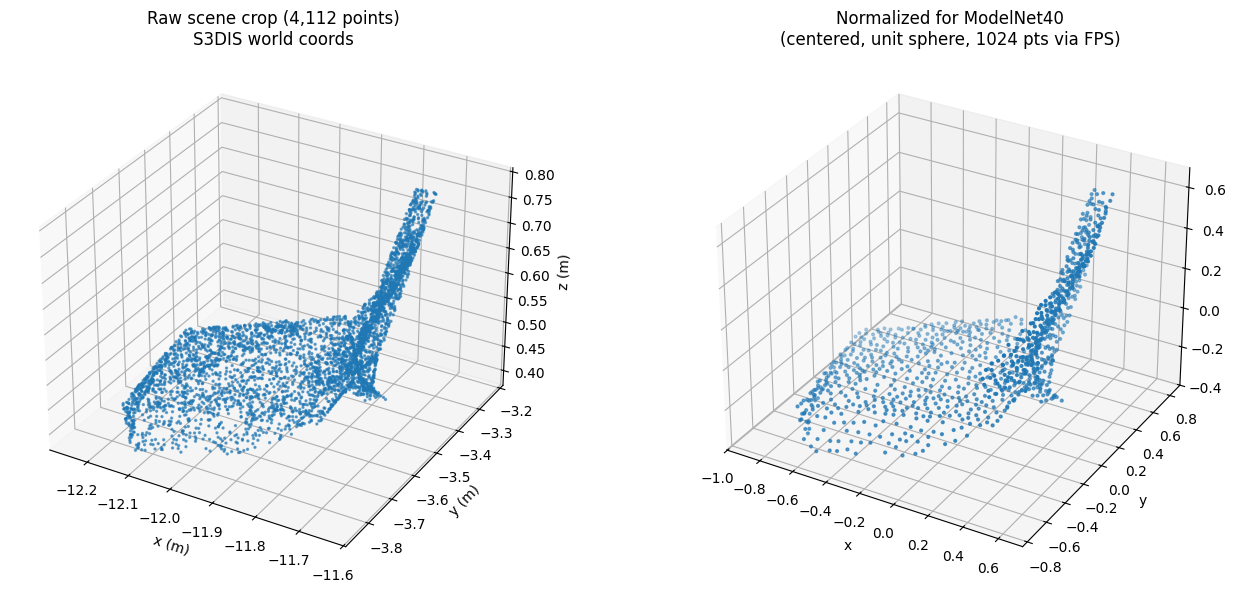


=== Classification ===
  True class    : chair  (S3DIS ground truth)
  Predicted     : laptop  (confidence 0.620)
  Correct?      : NO

  Top-5 predictions:
    1. laptop         0.6200
    2. bed            0.0734
    3. chair          0.0609  <-- true class
    4. tent           0.0246
    5. range_hood     0.0139


In [10]:
def normalize_for_modelnet40(points_xyz, num_points=1024, device=None):
    """Convert raw scene-crop points to ModelNet40 input format."""
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")

    pts = points_xyz.astype(np.float32).copy()
    pts = pts - pts.mean(axis=0, keepdims=True)
    max_r = np.linalg.norm(pts, axis=1).max()
    if max_r > 0:
        pts = pts / max_r
    pts_t = torch.from_numpy(pts).unsqueeze(0).to(device)
    if pts_t.shape[1] >= num_points:
        idx = farthest_point_sample(pts_t, num_points)
        pts_t = index_points(pts_t, idx)
    else:
        n_needed = num_points - pts_t.shape[1]
        pad_idx = torch.randint(0, pts_t.shape[1], (1, n_needed), device=device)
        pad = index_points(pts_t, pad_idx)
        pts_t = torch.cat([pts_t, pad], dim=1)
    return pts_t


def classify_crop(points_xyz, model, num_points=1024, top_k=5):
    pts_t = normalize_for_modelnet40(points_xyz, num_points=num_points)
    with torch.no_grad():
        logits = model(pts_t)
        probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    top_idx = np.argsort(probs)[::-1][:top_k]
    top_list = [(IDX_TO_CLASS_M40[i], probs[i]) for i in top_idx]
    return IDX_TO_CLASS_M40[top_idx[0]], probs[top_idx[0]], top_list


chair_objs = [o for o in objects if o["class_name"] == "chair"]
print(f"Found {len(chair_objs)} chairs in this room")
chair = chair_objs[0]
raw_pts = chair["points"][:, :3]
print(f"\nChair #1 (instance {chair['instance_id']}):")
print(f"  Raw point count : {raw_pts.shape[0]:,}")
print(f"  Bbox (m)        : x[{chair['bbox'][0]:.2f}, {chair['bbox'][3]:.2f}]  "
      f"y[{chair['bbox'][1]:.2f}, {chair['bbox'][4]:.2f}]  "
      f"z[{chair['bbox'][2]:.2f}, {chair['bbox'][5]:.2f}]")
print(f"  Dimensions (m)  : {chair['bbox'][3]-chair['bbox'][0]:.2f} × "
      f"{chair['bbox'][4]-chair['bbox'][1]:.2f} × {chair['bbox'][5]-chair['bbox'][2]:.2f}")

norm_t = normalize_for_modelnet40(raw_pts)
norm_pts = norm_t.squeeze(0).cpu().numpy()

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(raw_pts[:, 0], raw_pts[:, 1], raw_pts[:, 2], s=2, alpha=0.6)
ax1.set_title(f"Raw scene crop ({raw_pts.shape[0]:,} points)\nS3DIS world coords")
ax1.set_xlabel("x (m)"); ax1.set_ylabel("y (m)"); ax1.set_zlabel("z (m)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(norm_pts[:, 0], norm_pts[:, 1], norm_pts[:, 2], s=4)
ax2.set_title(f"Normalized for ModelNet40\n(centered, unit sphere, 1024 pts via FPS)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout()
plt.show()

pred_class, confidence, top_5 = classify_crop(raw_pts, model)
print(f"\n=== Classification ===")
print(f"  True class    : chair  (S3DIS ground truth)")
print(f"  Predicted     : {pred_class}  (confidence {confidence:.3f})")
print(f"  Correct?      : {'YES' if pred_class == 'chair' else 'NO'}")
print(f"\n  Top-5 predictions:")
for i, (cls, prob) in enumerate(top_5, 1):
    marker = "  <-- true class" if cls == "chair" else ""
    print(f"    {i}. {cls:<14} {prob:.4f}{marker}")

## Tabulating Results by looping over all chairs, tables and doors

In [11]:
from collections import defaultdict

# Filter to only objects with a ModelNet40 mapping
testable = [o for o in objects if o["mn40_class"] is not None]
print(f"Testable objects: {len(testable)}")
for cn, count in sorted({o["class_name"]: sum(1 for o in testable if o["class_name"] == cn)
                         for o in testable}.items()):
    print(f"  {cn:<12} {count}")
print()

# Run classification on each
results = []
print(f"{'idx':>3}  {'true':<10}  {'predicted':<14}  {'conf':>6}  {'top-3':<50}  {'OK?'}")
print("-" * 100)

for i, obj in enumerate(testable):
    true_cls = obj["mn40_class"]
    raw_pts = obj["points"][:, :3]
    pred_cls, conf, top5 = classify_crop(raw_pts, model, top_k=5)
    correct = (pred_cls == true_cls)
    
    bbox = obj["bbox"]
    dims = (bbox[3]-bbox[0], bbox[4]-bbox[1], bbox[5]-bbox[2])
    
    results.append({
        "idx": i, "instance": f"{obj['class_name']}_{obj['instance_id']}",
        "true": true_cls, "pred": pred_cls, "conf": conf, "correct": correct,
        "top5": top5, "n_points": raw_pts.shape[0],
        "dims_xyz": dims,
    })
    
    top3_str = ", ".join(f"{c}({p:.2f})" for c, p in top5[:3])
    ok = "✓" if correct else "✗"
    print(f"{i:>3}  {true_cls:<10}  {pred_cls:<14}  {conf:>6.3f}  {top3_str:<50}  {ok}")

# Summary
print("\n" + "=" * 70)
print("SIM-TO-REAL ACCURACY")
print("=" * 70)
overall = sum(r["correct"] for r in results) / len(results)
print(f"  Overall: {overall:.4f}  ({sum(r['correct'] for r in results)}/{len(results)})")

per_class = defaultdict(lambda: [0, 0])  # [correct, total]
for r in results:
    per_class[r["true"]][1] += 1
    if r["correct"]:
        per_class[r["true"]][0] += 1

print(f"\nPer-class:")
for cls, (correct, total) in sorted(per_class.items()):
    acc = correct / total
    print(f"  {cls:<10}  {correct}/{total}   acc = {acc:.4f}")

# Compare to clean ModelNet40 (which we know from Step 1)
print(f"\nReference: clean ModelNet40 test acc was 0.8987 (89.87%)")
print(f"Sim-to-real gap: {0.8987 - overall:+.4f} ({(0.8987 - overall)*100:+.1f} percentage points)")

Testable objects: 12
  chair        0
  door         0
  table        0

idx  true        predicted         conf  top-3                                               OK?
----------------------------------------------------------------------------------------------------
  0  chair       laptop           0.700  laptop(0.70), chair(0.05), bed(0.04)                ✗
  1  chair       tent             0.431  tent(0.43), laptop(0.14), bed(0.07)                 ✗
  2  chair       tent             0.319  tent(0.32), monitor(0.18), chair(0.09)              ✗
  3  chair       laptop           0.254  laptop(0.25), bed(0.24), tent(0.15)                 ✗
  4  chair       chair            0.291  chair(0.29), laptop(0.26), tent(0.06)               ✓
  5  chair       chair            0.256  chair(0.26), monitor(0.12), tent(0.10)              ✓
  6  chair       chair            0.327  chair(0.33), laptop(0.16), airplane(0.08)           ✓
  7  chair       laptop           0.413  laptop(0.41), chair(0.1

## Visualizing misclassified chair vs correctly-classified chair vs clean ModelNet40 chair

Worst misclassified chair: idx 0 (chair_1) -> 'laptop' @ 0.700
Best correct chair       : idx 8 (chair_9) -> 'chair' @ 0.836


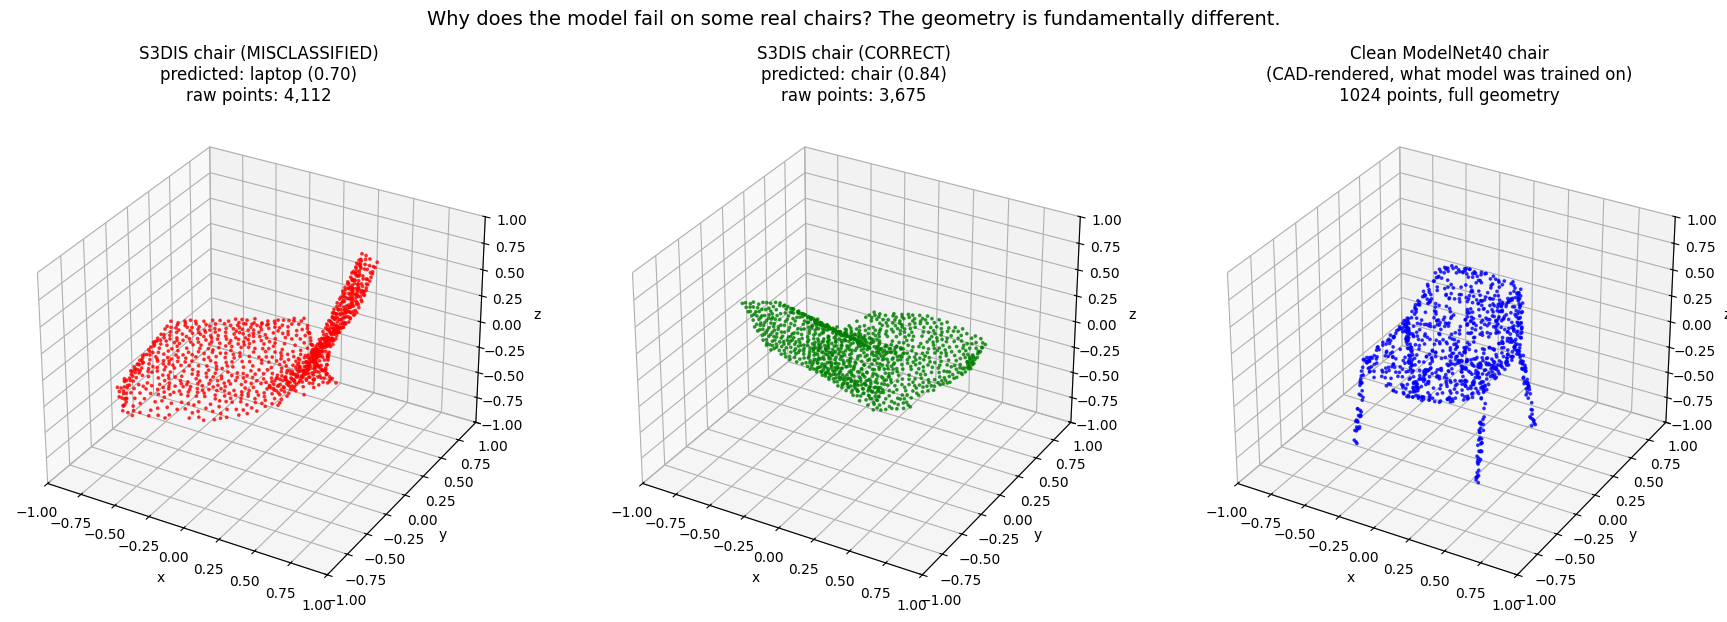


--- Aspect ratio analysis ---
  object                          x_range  y_range  z_range   tallness
  MISCLASSIFIED real chair          1.529    1.544    0.957      0.620
  CORRECT real chair                1.245    1.286    1.060      0.824
  Clean ModelNet40 chair            0.906    0.927    1.251      1.349


In [12]:
# Pick the worst-misclassified chair (highest-confidence wrong)
wrong_chairs = [r for r in results if r["true"] == "chair" and not r["correct"]]
right_chairs = [r for r in results if r["true"] == "chair" and r["correct"]]

worst_wrong = max(wrong_chairs, key=lambda r: r["conf"])
best_right  = max(right_chairs, key=lambda r: r["conf"])

print(f"Worst misclassified chair: idx {worst_wrong['idx']} ({worst_wrong['instance']}) "
      f"-> '{worst_wrong['pred']}' @ {worst_wrong['conf']:.3f}")
print(f"Best correct chair       : idx {best_right['idx']} ({best_right['instance']}) "
      f"-> 'chair' @ {best_right['conf']:.3f}")

# Get their raw points
wrong_obj = testable[worst_wrong["idx"]]
right_obj = testable[best_right["idx"]]
wrong_pts = wrong_obj["points"][:, :3]
right_pts = right_obj["points"][:, :3]

# Normalize both for comparison (this is what the model actually sees)
wrong_norm = normalize_for_modelnet40(wrong_pts).squeeze(0).cpu().numpy()
right_norm = normalize_for_modelnet40(right_pts).squeeze(0).cpu().numpy()

# Also load one clean ModelNet40 chair for reference
cache_path = os.path.join(CACHE_DIR_M40, "test.npz")
data = np.load(cache_path)
mn40_chairs = np.where(data["labels"] == CLASS_TO_IDX_M40["chair"])[0]
clean_chair_idx = mn40_chairs[0]
clean_pts = data["points"][clean_chair_idx]

# Plot all three normalized point clouds side by side
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.scatter(wrong_norm[:, 0], wrong_norm[:, 1], wrong_norm[:, 2], s=3, c="red", alpha=0.7)
ax1.set_title(f"S3DIS chair (MISCLASSIFIED)\npredicted: {worst_wrong['pred']} ({worst_wrong['conf']:.2f})\n"
              f"raw points: {wrong_pts.shape[0]:,}")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax1.set_xlim(-1, 1); ax1.set_ylim(-1, 1); ax1.set_zlim(-1, 1)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.scatter(right_norm[:, 0], right_norm[:, 1], right_norm[:, 2], s=3, c="green", alpha=0.7)
ax2.set_title(f"S3DIS chair (CORRECT)\npredicted: chair ({best_right['conf']:.2f})\n"
              f"raw points: {right_pts.shape[0]:,}")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.set_xlim(-1, 1); ax2.set_ylim(-1, 1); ax2.set_zlim(-1, 1)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.scatter(clean_pts[:, 0], clean_pts[:, 1], clean_pts[:, 2], s=3, c="blue", alpha=0.7)
ax3.set_title(f"Clean ModelNet40 chair\n(CAD-rendered, what model was trained on)\n"
              f"1024 points, full geometry")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_xlim(-1, 1); ax3.set_ylim(-1, 1); ax3.set_zlim(-1, 1)

plt.suptitle("Why does the model fail on some real chairs? The geometry is fundamentally different.", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "scene_crop_chair_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

# Also print dim ratios for analysis
print("\n--- Aspect ratio analysis ---")
print(f"  {'object':<30}  {'x_range':>7}  {'y_range':>7}  {'z_range':>7}  {'tallness':>9}")
for label, pts in [("MISCLASSIFIED real chair", wrong_norm),
                   ("CORRECT real chair", right_norm),
                   ("Clean ModelNet40 chair", clean_pts)]:
    xr = pts[:, 0].max() - pts[:, 0].min()
    yr = pts[:, 1].max() - pts[:, 1].min()
    zr = pts[:, 2].max() - pts[:, 2].min()
    tallness = zr / max(xr, yr)
    print(f"  {label:<30}  {xr:>7.3f}  {yr:>7.3f}  {zr:>7.3f}  {tallness:>9.3f}")

## Multi-room evaluation

In [14]:
# Loop over all rooms in Area_5 and aggregate
ALL_ROOMS = sorted([d for d in os.listdir(AREA_5_DIR)
                    if os.path.isdir(os.path.join(AREA_5_DIR, d))
                    and not d.startswith(".")])

print(f"Testing across all {len(ALL_ROOMS)} rooms in Area_5...\n")

all_results = []   # one entry per object, across all rooms
room_summary = []  # one entry per room

t_start = time.time()
for r_i, room_name in enumerate(ALL_ROOMS):
    room_dir = os.path.join(AREA_5_DIR, room_name)
    try:
        room_objs = load_s3dis_annotations(room_dir)
    except Exception as e:
        print(f"  [skip] {room_name}: {e}")
        continue

    # Only classify objects with a MN40 mapping
    testable_room = [o for o in room_objs if o["mn40_class"] is not None]
    if not testable_room:
        continue

    room_correct = 0
    for obj in testable_room:
        try:
            true_cls = obj["mn40_class"]
            raw_pts = obj["points"][:, :3]
            pred_cls, conf, top5 = classify_crop(raw_pts, model, top_k=5)
            correct = (pred_cls == true_cls)
            all_results.append({
                "room": room_name,
                "instance": f"{obj['class_name']}_{obj['instance_id']}",
                "true": true_cls, "pred": pred_cls,
                "conf": conf, "correct": correct,
                "n_points": raw_pts.shape[0],
            })
            if correct:
                room_correct += 1
        except Exception as e:
            print(f"  [obj fail] {room_name}/{obj['class_name']}_{obj['instance_id']}: {e}")

    room_summary.append({
        "room": room_name,
        "n_objects": len(testable_room),
        "n_correct": room_correct,
        "acc": room_correct / len(testable_room) if testable_room else 0.0,
    })
    print(f"  [{r_i+1:2d}/{len(ALL_ROOMS)}] {room_name:<25} {room_correct:>3}/{len(testable_room):<3}  "
          f"acc {room_correct/len(testable_room):.3f}")

print(f"\nTotal time: {time.time()-t_start:.1f}s")

# ============ Aggregate ============
print("\n" + "=" * 70)
print("AREA_5 SIM-TO-REAL SUMMARY")
print("=" * 70)

n_total = len(all_results)
n_correct = sum(r["correct"] for r in all_results)
overall = n_correct / n_total if n_total else 0
print(f"  Total objects classified: {n_total}")
print(f"  Overall accuracy        : {overall:.4f}  ({n_correct}/{n_total})")
print(f"  Sim-to-real gap         : {0.8987 - overall:+.4f} ({(0.8987-overall)*100:+.1f} pp)")

per_class = defaultdict(lambda: [0, 0, []])  # [correct, total, confidences]
for r in all_results:
    per_class[r["true"]][1] += 1
    per_class[r["true"]][2].append(r["conf"])
    if r["correct"]:
        per_class[r["true"]][0] += 1

print(f"\n  Per-class:")
print(f"    {'class':<12}  {'correct':>7}  {'total':>5}  {'acc':>6}  {'avg_conf':>8}")
for cls, (correct, total, confs) in sorted(per_class.items()):
    acc = correct / total
    avg_conf = np.mean(confs) if confs else 0
    print(f"    {cls:<12}  {correct:>7}  {total:>5}  {acc:>6.3f}  {avg_conf:>8.3f}")

# What did chairs (when misclassified) get called?
print(f"\n  When the model got chairs WRONG, what did it predict?")
wrong_chair_preds = Counter(r["pred"] for r in all_results
                            if r["true"] == "chair" and not r["correct"])
for cls, count in wrong_chair_preds.most_common(8):
    print(f"    {cls:<12}  {count} times")

# Save results to CSV for the writeup
import csv
csv_path = os.path.join(PROJECT_ROOT, "scene_crop_results_area5.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["room", "instance", "true", "pred", "conf", "correct", "n_points"])
    writer.writeheader()
    writer.writerows(all_results)
print(f"\nResults CSV saved: {csv_path}")

Testing across all 68 rooms in Area_5...

  [ 1/68] WC_1                        1/1    acc 1.000
  [ 2/68] WC_2                        1/1    acc 1.000
  [ 3/68] conferenceRoom_1            7/12   acc 0.583
  [ 4/68] conferenceRoom_2           23/23   acc 1.000
  [ 5/68] conferenceRoom_3           13/22   acc 0.591
  [ 6/68] hallway_1                   1/6    acc 0.167
  [ 7/68] hallway_10                  1/6    acc 0.167
  [ 8/68] hallway_11                  1/2    acc 0.500
  [ 9/68] hallway_12                  1/2    acc 0.500
  [10/68] hallway_13                  0/3    acc 0.000
  [11/68] hallway_14                  2/3    acc 0.667
  [12/68] hallway_15                  0/2    acc 0.000
  [13/68] hallway_2                   6/22   acc 0.273
  [14/68] hallway_3                   1/2    acc 0.500
  [15/68] hallway_4                   0/7    acc 0.000
  [16/68] hallway_5                   3/16   acc 0.188
  [skip] hallway_6: the number of columns changed from 6 to 5 at row 180389; u

## 40×40 confusion matrix + per-class failure analysis


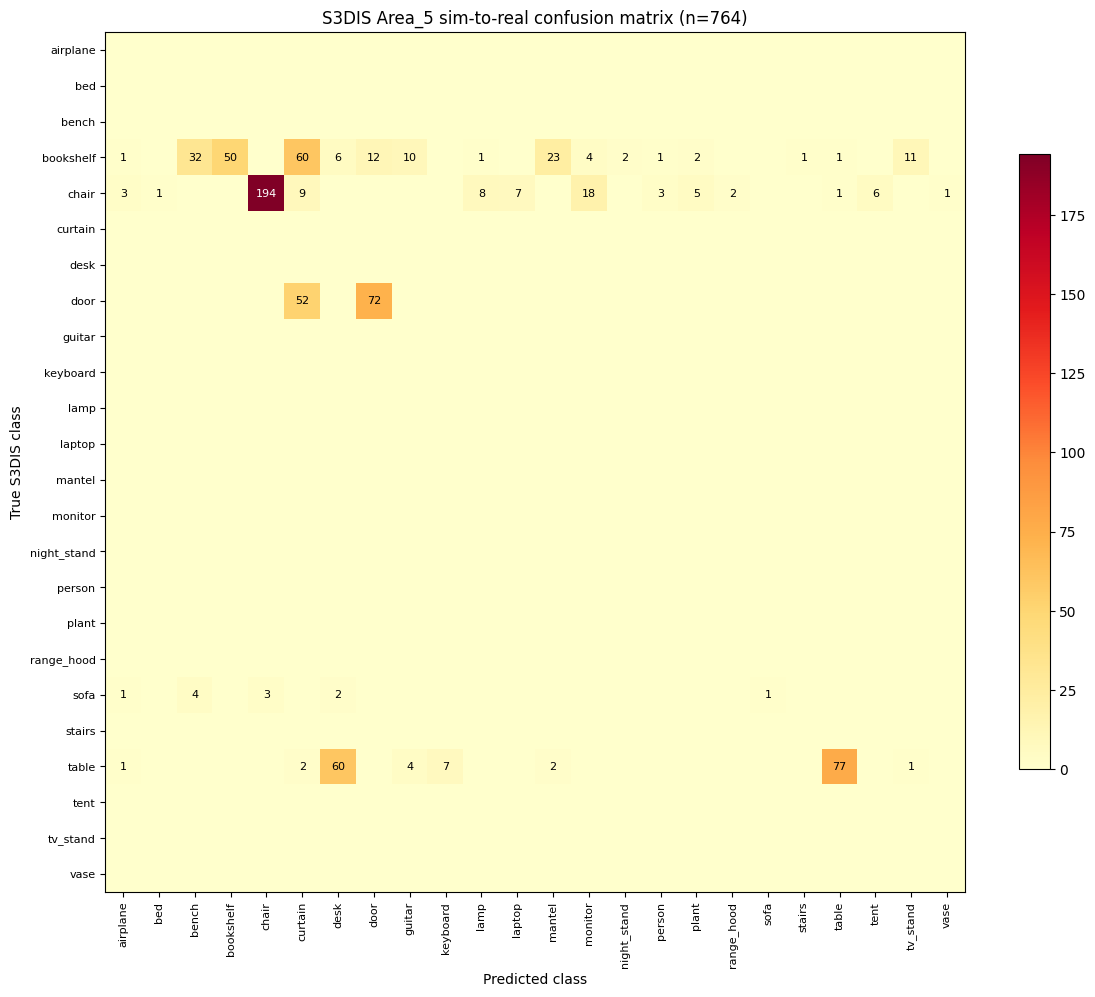


PER-CLASS FAILURE MODES

  CHAIR: 194/258 correct (75.2%)
  When wrong, predicted as:
    monitor           18  (28.1% of mistakes)
    curtain            9  (14.1% of mistakes)
    lamp               8  (12.5% of mistakes)
    laptop             7  (10.9% of mistakes)
    tent               6  (9.4% of mistakes)
  Avg confidence — wrong: 0.369, right: 0.806

  TABLE: 77/154 correct (50.0%)
  When wrong, predicted as:
    desk              60  (77.9% of mistakes)
    keyboard           7  (9.1% of mistakes)
    guitar             4  (5.2% of mistakes)
    curtain            2  (2.6% of mistakes)
    mantel             2  (2.6% of mistakes)
  Avg confidence — wrong: 0.542, right: 0.608

  SOFA: 1/11 correct (9.1%)
  When wrong, predicted as:
    bench              4  (40.0% of mistakes)
    chair              3  (30.0% of mistakes)
    desk               2  (20.0% of mistakes)
    airplane           1  (10.0% of mistakes)
  Avg confidence — wrong: 0.561, right: 0.918

  BOOKSHELF: 50/2

In [15]:
from sklearn.metrics import confusion_matrix as sk_cm
from collections import defaultdict, Counter

# Get all true and predicted labels as MN40 indices
true_idx = []
pred_idx = []
for r in all_results:
    true_idx.append(CLASS_TO_IDX_M40[r["true"]])
    pred_idx.append(CLASS_TO_IDX_M40[r["pred"]])
true_idx = np.array(true_idx)
pred_idx = np.array(pred_idx)

# Find only the classes that actually appear (true OR predicted)
classes_appearing = sorted(set(true_idx.tolist() + pred_idx.tolist()))
class_names_appearing = [CLASSES_M40[i] for i in classes_appearing]

# Confusion matrix restricted to those classes
cm = sk_cm(true_idx, pred_idx, labels=classes_appearing)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="YlOrRd")
ax.set_xticks(range(len(classes_appearing)))
ax.set_yticks(range(len(classes_appearing)))
ax.set_xticklabels(class_names_appearing, rotation=90, fontsize=8)
ax.set_yticklabels(class_names_appearing, fontsize=8)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True S3DIS class")
ax.set_title(f"S3DIS Area_5 sim-to-real confusion matrix (n={len(all_results)})")

# Annotate non-zero cells
for i in range(len(classes_appearing)):
    for j in range(len(classes_appearing)):
        if cm[i, j] > 0:
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "simtoreal_confusion_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()

# Per-class failure mode breakdown
print("\n" + "=" * 70)
print("PER-CLASS FAILURE MODES")
print("=" * 70)

for true_cls in ["chair", "table", "sofa", "bookshelf", "door"]:
    wrong = [r for r in all_results if r["true"] == true_cls and not r["correct"]]
    correct = [r for r in all_results if r["true"] == true_cls and r["correct"]]
    total = len(wrong) + len(correct)
    if total == 0:
        continue

    print(f"\n  {true_cls.upper()}: {len(correct)}/{total} correct ({100*len(correct)/total:.1f}%)")
    print(f"  When wrong, predicted as:")
    pred_dist = Counter(r["pred"] for r in wrong)
    for cls, count in pred_dist.most_common(5):
        pct = 100 * count / len(wrong) if wrong else 0
        print(f"    {cls:<14}  {count:>4}  ({pct:.1f}% of mistakes)")

    # Avg confidence when wrong vs right
    if wrong:
        avg_conf_wrong = np.mean([r["conf"] for r in wrong])
    else:
        avg_conf_wrong = 0
    if correct:
        avg_conf_right = np.mean([r["conf"] for r in correct])
    else:
        avg_conf_right = 0
    print(f"  Avg confidence — wrong: {avg_conf_wrong:.3f}, right: {avg_conf_right:.3f}")

## Test-Time Augmentation

In [25]:
def classify_crop_tta(points_xyz, model, n_rotations=8, num_points=1024):
    """Classify with test-time augmentation: average softmax over n rotations."""
    pts = points_xyz.astype(np.float32).copy()
    # Center + scale
    pts = pts - pts.mean(axis=0, keepdims=True)
    max_r = np.linalg.norm(pts, axis=1).max()
    if max_r > 0:
        pts = pts / max_r

    # Sample to num_points using FPS once (deterministic)
    pts_t = torch.from_numpy(pts).unsqueeze(0).to(device)
    if pts_t.shape[1] >= num_points:
        idx = farthest_point_sample(pts_t, num_points)
        pts_t = index_points(pts_t, idx)
    else:
        n_needed = num_points - pts_t.shape[1]
        pad_idx = torch.randint(0, pts_t.shape[1], (1, n_needed), device=device)
        pad = index_points(pts_t, pad_idx)
        pts_t = torch.cat([pts_t, pad], dim=1)

    # Average softmax over n rotations around z-axis
    all_probs = []
    angles = np.linspace(0, 2 * np.pi, n_rotations, endpoint=False)
    with torch.no_grad():
        for theta in angles:
            c, s = np.cos(theta), np.sin(theta)
            R = torch.tensor([[c, -s, 0.0],
                              [s,  c, 0.0],
                              [0.0, 0.0, 1.0]], dtype=torch.float32, device=device)
            rotated = pts_t @ R.T
            logits = model(rotated)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs)
    avg_probs = torch.stack(all_probs).mean(dim=0).squeeze(0).cpu().numpy()
    top_idx = avg_probs.argsort()[::-1][:5]
    return IDX_TO_CLASS_M40[top_idx[0]], avg_probs[top_idx[0]], [(IDX_TO_CLASS_M40[i], avg_probs[i]) for i in top_idx]


# Re-run evaluation across all rooms WITH TTA
print(f"Re-evaluating {len(all_results)} objects with TTA (8 rotations)...")
print("This takes ~10 minutes — 8x slower than the original eval.\n")

tta_results = []
t_start = time.time()
for i, r in enumerate(all_results):
    # We need the raw points back — re-locate the object
    room_dir = os.path.join(AREA_5_DIR, r["room"])
    room_objs = load_s3dis_annotations(room_dir)
    target = None
    for o in room_objs:
        if f"{o['class_name']}_{o['instance_id']}" == r["instance"]:
            target = o
            break
    if target is None:
        continue

    raw_pts = target["points"][:, :3]
    pred_cls, conf, top5 = classify_crop_tta(raw_pts, model, n_rotations=8)
    correct = (pred_cls == r["true"])
    tta_results.append({**r, "tta_pred": pred_cls, "tta_conf": conf, "tta_correct": correct})

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(all_results)}] elapsed {time.time()-t_start:.0f}s")

# Compare
print("\n" + "=" * 70)
print("TTA RESULTS (n=8 rotations)")
print("=" * 70)
n_total = len(tta_results)
n_correct_orig = sum(r["correct"] for r in tta_results)
n_correct_tta = sum(r["tta_correct"] for r in tta_results)
print(f"  Original (no TTA): {n_correct_orig}/{n_total}  acc {n_correct_orig/n_total:.4f}")
print(f"  With TTA         : {n_correct_tta}/{n_total}  acc {n_correct_tta/n_total:.4f}")
print(f"  Delta            : {(n_correct_tta - n_correct_orig)/n_total:+.4f}")

# Per-class breakdown
print(f"\n  Per-class:")
print(f"    {'class':<12}  {'no_tta':>7}  {'with_tta':>9}  {'delta':>7}")
for cls in ["chair", "table", "sofa", "bookshelf", "door"]:
    cls_results = [r for r in tta_results if r["true"] == cls]
    if not cls_results:
        continue
    orig_acc = sum(r["correct"] for r in cls_results) / len(cls_results)
    tta_acc = sum(r["tta_correct"] for r in cls_results) / len(cls_results)
    print(f"    {cls:<12}  {orig_acc:>7.3f}  {tta_acc:>9.3f}  {tta_acc-orig_acc:>+7.3f}")

Re-evaluating 764 objects with TTA (8 rotations)...
This takes ~10 minutes — 8x slower than the original eval.

  [50/764] elapsed 101s
  [100/764] elapsed 227s
  [150/764] elapsed 376s
  [200/764] elapsed 523s
  [250/764] elapsed 671s
  [300/764] elapsed 826s
  [350/764] elapsed 987s
  [400/764] elapsed 1151s
  [450/764] elapsed 1303s
  [500/764] elapsed 1453s
  [550/764] elapsed 1602s
  [600/764] elapsed 1801s
  [650/764] elapsed 1985s
  [700/764] elapsed 2163s
  [750/764] elapsed 2314s

TTA RESULTS (n=8 rotations)
  Original (no TTA): 389/764  acc 0.5092
  With TTA         : 392/764  acc 0.5131
  Delta            : +0.0039

  Per-class:
    class          no_tta   with_tta    delta
    chair           0.744      0.748   +0.004
    table           0.494      0.474   -0.019
    sofa            0.091      0.091   +0.000
    bookshelf       0.217      0.240   +0.023
    door            0.589      0.589   +0.000


## Semantic equivalence remapping

In [16]:
# Define semantic equivalence groups
# STRICT: only obvious cases where S3DIS bundles things ModelNet40 splits
SEMANTIC_STRICT = {
    "table": {"table", "desk"},     # S3DIS table contains desks (no separate class)
}

# PERMISSIVE: also accept geometric/functional siblings the model can't distinguish
SEMANTIC_PERMISSIVE = {
    "table":     {"table", "desk"},
    "door":      {"door", "curtain"},                   # both vertical hanging panels
    "bookshelf": {"bookshelf", "tv_stand", "wardrobe"}, # all tall rectangular storage
    "sofa":      {"sofa", "bench"},                     # both low horizontal seating
}


def evaluate_with_mapping(results, mapping):
    """Count predictions as correct if they're in the semantic equivalent set."""
    n_correct = 0
    per_class = defaultdict(lambda: [0, 0])
    for r in results:
        true = r["true"]
        pred = r["pred"]
        acceptable = mapping.get(true, {true})   # default: exact match only
        if pred in acceptable:
            n_correct += 1
            per_class[true][0] += 1
        per_class[true][1] += 1
    return n_correct, per_class


n_total = len(all_results)
n_baseline = sum(r["correct"] for r in all_results)

print("=" * 75)
print("SEMANTIC EQUIVALENCE REMAPPING")
print("=" * 75)
print(f"Total S3DIS Area_5 objects: {n_total}\n")

# Headline summary
print(f"{'Mapping':<35}  {'Correct':>8}  {'Accuracy':>9}  {'gain':>7}")
print("-" * 75)
print(f"{'Baseline (strict 1:1)':<35}  {n_baseline:>8}  {n_baseline/n_total:>9.4f}  {'':>7}")

strict_correct, strict_pc = evaluate_with_mapping(all_results, SEMANTIC_STRICT)
print(f"{'Strict (table = table+desk)':<35}  {strict_correct:>8}  {strict_correct/n_total:>9.4f}  "
      f"{(strict_correct - n_baseline)/n_total:>+7.4f}")

perm_correct, perm_pc = evaluate_with_mapping(all_results, SEMANTIC_PERMISSIVE)
print(f"{'Permissive (all equivalents)':<35}  {perm_correct:>8}  {perm_correct/n_total:>9.4f}  "
      f"{(perm_correct - n_baseline)/n_total:>+7.4f}")

# Per-class impact
print("\n" + "=" * 75)
print("PER-CLASS IMPACT")
print("=" * 75)
print(f"{'class':<12}  {'baseline':>10}  {'strict':>10}  {'permissive':>11}  {'mapping rule'}")
print("-" * 75)

rule_descriptions = {
    "chair":     "no change — strict mapping",
    "table":     "+ desk → table",
    "sofa":      "+ bench → sofa (permissive only)",
    "bookshelf": "+ tv_stand, wardrobe → bookshelf (permissive)",
    "door":      "+ curtain → door (permissive)",
}

for cls in ["chair", "table", "sofa", "bookshelf", "door"]:
    base_c = sum(1 for r in all_results if r["true"] == cls and r["correct"])
    base_n = sum(1 for r in all_results if r["true"] == cls)
    if base_n == 0:
        continue
    base_a = base_c / base_n
    strict_a = strict_pc[cls][0] / strict_pc[cls][1] if strict_pc[cls][1] else 0
    perm_a   = perm_pc[cls][0] / perm_pc[cls][1] if perm_pc[cls][1] else 0
    print(f"{cls:<12}  {base_a:>10.3f}  {strict_a:>10.3f}  {perm_a:>11.3f}  {rule_descriptions.get(cls, '')}")

# Sim-to-real gap framing
print(f"\n" + "=" * 75)
print(f"SIM-TO-REAL GAP (vs clean ModelNet40 0.8987)")
print("=" * 75)
print(f"  Baseline             : gap {0.8987 - n_baseline/n_total:+.4f}  ({100*(0.8987 - n_baseline/n_total):.1f}pp)")
print(f"  After strict remap   : gap {0.8987 - strict_correct/n_total:+.4f}  ({100*(0.8987 - strict_correct/n_total):.1f}pp)")
print(f"  After permissive     : gap {0.8987 - perm_correct/n_total:+.4f}  ({100*(0.8987 - perm_correct/n_total):.1f}pp)")

SEMANTIC EQUIVALENCE REMAPPING
Total S3DIS Area_5 objects: 764

Mapping                               Correct   Accuracy     gain
---------------------------------------------------------------------------
Baseline (strict 1:1)                     394     0.5157         
Strict (table = table+desk)               454     0.5942  +0.0785
Permissive (all equivalents)              521     0.6819  +0.1662

PER-CLASS IMPACT
class           baseline      strict   permissive  mapping rule
---------------------------------------------------------------------------
chair              0.752       0.752        0.752  no change — strict mapping
table              0.500       0.890        0.890  + desk → table
sofa               0.091       0.091        0.455  + bench → sofa (permissive only)
bookshelf          0.230       0.230        0.281  + tv_stand, wardrobe → bookshelf (permissive)
door               0.581       0.581        1.000  + curtain → door (permissive)

SIM-TO-REAL GAP (vs clean Model

## Re-evaluating model after domain augmentation on S3DIS Area_5

In [19]:
# Path to the new checkpoint
domain_aug_path = os.path.join(CHECKPOINT_DIR, "pointnetpp_msg_domain_aug_best.pt")
assert os.path.exists(domain_aug_path), f"Missing: {domain_aug_path}. Download from Kaggle first."

# Save the ORIGINAL results (baseline MSG) so we can compare side-by-side
original_results = all_results.copy() if 'all_results' in dir() else None
if original_results is None:
    print("Note: 'all_results' from earlier eval not found in memory.")
    print("If you restarted the kernel, re-run Cell 13 (baseline evaluation) first.")
    raise RuntimeError("Baseline results missing")

# Load the NEW checkpoint into the existing model
ckpt_new = torch.load(domain_aug_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt_new["model"])
model.eval()
print(f"Loaded domain-aug checkpoint:")
print(f"  Epoch     : {ckpt_new.get('epoch', '?')}")
print(f"  Clean acc : {ckpt_new.get('val_acc', '?')}  (was 0.8987 for original MSG)")
print(f"  Weights   : {'EMA' if ckpt_new.get('is_ema') else 'raw'}\n")

# ============ Re-run multi-room eval with the new model ============
print(f"Re-evaluating ~764 objects with NEW (domain-aug) model...")
new_results = []
t_start = time.time()
for r_i, room_name in enumerate(ALL_ROOMS):
    room_dir = os.path.join(AREA_5_DIR, room_name)
    try:
        room_objs = load_s3dis_annotations(room_dir)
    except Exception as e:
        continue
    testable_room = [o for o in room_objs if o["mn40_class"] is not None]
    if not testable_room:
        continue
    for obj in testable_room:
        try:
            true_cls = obj["mn40_class"]
            raw_pts = obj["points"][:, :3]
            pred_cls, conf, top5 = classify_crop(raw_pts, model, top_k=5)
            correct = (pred_cls == true_cls)
            new_results.append({
                "room": room_name,
                "instance": f"{obj['class_name']}_{obj['instance_id']}",
                "true": true_cls, "pred": pred_cls,
                "conf": conf, "correct": correct,
                "n_points": raw_pts.shape[0],
            })
        except Exception:
            continue
    if (r_i + 1) % 10 == 0:
        print(f"  [{r_i+1}/{len(ALL_ROOMS)}] rooms processed in {time.time()-t_start:.0f}s")

print(f"\nDone in {time.time()-t_start:.0f}s\n")

# ============ Compare baselines (no remap) ============
n_total = len(new_results)
n_correct_orig = sum(r["correct"] for r in original_results)
n_correct_new  = sum(r["correct"] for r in new_results)

print("=" * 75)
print("STEP 3 RESULTS — Original MSG vs Domain-Aug MSG on S3DIS Area_5")
print("=" * 75)
print(f"\n  No semantic remapping:")
print(f"    Original MSG       : {n_correct_orig}/{n_total}  acc {n_correct_orig/n_total:.4f}")
print(f"    Domain-aug MSG     : {n_correct_new}/{n_total}  acc {n_correct_new/n_total:.4f}")
print(f"    Delta              : {(n_correct_new - n_correct_orig)/n_total:+.4f}  "
      f"({(n_correct_new - n_correct_orig)*100/n_total:+.1f}pp)")

# ============ Per-class breakdown ============
print(f"\n  Per-class accuracy:")
print(f"    {'class':<12}  {'original':>10}  {'domain-aug':>11}  {'delta':>8}")
print(f"    {'-'*45}")
for cls in ["chair", "table", "sofa", "bookshelf", "door"]:
    orig_results = [r for r in original_results if r["true"] == cls]
    new_results_cls = [r for r in new_results if r["true"] == cls]
    if not orig_results or not new_results_cls:
        continue
    orig_acc = sum(r["correct"] for r in orig_results) / len(orig_results)
    new_acc = sum(r["correct"] for r in new_results_cls) / len(new_results_cls)
    print(f"    {cls:<12}  {orig_acc:>10.3f}  {new_acc:>11.3f}  {new_acc - orig_acc:>+8.3f}")

# ============ Apply semantic remap to both ============
SEMANTIC_STRICT = {"table": {"table", "desk"}}
SEMANTIC_PERMISSIVE = {
    "table":     {"table", "desk"},
    "door":      {"door", "curtain"},
    "bookshelf": {"bookshelf", "tv_stand", "wardrobe"},
    "sofa":      {"sofa", "bench"},
}

def eval_with_map(results, mapping):
    return sum(1 for r in results if r["pred"] in mapping.get(r["true"], {r["true"]}))

orig_strict = eval_with_map(original_results, SEMANTIC_STRICT)
new_strict  = eval_with_map(new_results, SEMANTIC_STRICT)
orig_perm   = eval_with_map(original_results, SEMANTIC_PERMISSIVE)
new_perm    = eval_with_map(new_results, SEMANTIC_PERMISSIVE)

print(f"\n  With STRICT remap (table = table+desk):")
print(f"    Original MSG       : acc {orig_strict/n_total:.4f}")
print(f"    Domain-aug MSG     : acc {new_strict/n_total:.4f}")
print(f"    Delta              : {(new_strict - orig_strict)/n_total:+.4f}")

print(f"\n  With PERMISSIVE remap (all equivalents):")
print(f"    Original MSG       : acc {orig_perm/n_total:.4f}")
print(f"    Domain-aug MSG     : acc {new_perm/n_total:.4f}")
print(f"    Delta              : {(new_perm - orig_perm)/n_total:+.4f}")

# ============ Save results to CSV ============
import csv
new_csv = os.path.join(PROJECT_ROOT, "scene_crop_results_domain_aug.csv")
with open(new_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["room", "instance", "true", "pred", "conf", "correct", "n_points"])
    writer.writeheader()
    writer.writerows(new_results)
print(f"\nNew results saved: {new_csv}")

Loaded domain-aug checkpoint:
  Epoch     : 60
  Clean acc : 0.8889789303079416  (was 0.8987 for original MSG)
  Weights   : EMA

Re-evaluating ~764 objects with NEW (domain-aug) model...
  [10/68] rooms processed in 41s
  [20/68] rooms processed in 68s
  [30/68] rooms processed in 119s
  [40/68] rooms processed in 182s
  [50/68] rooms processed in 224s
  [60/68] rooms processed in 303s

Done in 325s

STEP 3 RESULTS — Original MSG vs Domain-Aug MSG on S3DIS Area_5

  No semantic remapping:
    Original MSG       : 394/764  acc 0.5157
    Domain-aug MSG     : 474/764  acc 0.6204
    Delta              : +0.1047  (+10.5pp)

  Per-class accuracy:
    class           original   domain-aug     delta
    ---------------------------------------------
    chair              0.752        0.961    +0.209
    table              0.500        0.455    -0.045
    sofa               0.091        0.091    +0.000
    bookshelf          0.230        0.272    +0.041
    door               0.581        0.